In [79]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
from collections import Counter
warnings.filterwarnings('ignore')

AUTSL DATASET 


In [45]:
DATA_DIR = Path("data")
autsl_train = pd.read_csv(DATA_DIR / "AUTSL" / "train.csv")
autsl_val = pd.read_csv(DATA_DIR / "AUTSL" / "val.csv")
autsl_test = pd.read_csv(DATA_DIR / "AUTSL" / "test.csv")

In [46]:
print(f"  Train: {len(autsl_train)} samples")
print(f"  Val: {len(autsl_val)} samples")
print(f"  Test: {len(autsl_test)} samples")
print(f"  Total:  {len(autsl_train) + len(autsl_val) + len(autsl_test):,}")

  Train: 28142 samples
  Val: 4418 samples
  Test: 3742 samples
  Total:  36,302


In [47]:
class_mapping= DATA_DIR / "AUTSL" / "SignList_ClassId_TR_EN.csv"
if class_mapping.exists():
    class_mapping = pd.read_csv(class_mapping)
    print(f"\n✓ Class mapping loaded: {len(class_mapping)} classes")
    print(class_mapping.head())


✓ Class mapping loaded: 226 classes
   ClassId            TR               EN
0        0          abla           sister
1        1         acele            hurry
2        2       acikmak           hungry
3        3  afiyet_olsun  enjoy_your_meal
4        4        agabey          brother


In [48]:
print(f"Train columns: {autsl_train.columns.tolist()}")

Train columns: ['name', 'class_id']


In [49]:
video_col = autsl_train.columns[0] 
label_col = autsl_train.columns[1]


In [50]:
    
all_labels = pd.concat([
        autsl_train[label_col],
        autsl_val[label_col],
        autsl_test[label_col]
    ])
    
print(f"Number of unique classes: {all_labels.nunique()}")
print(f"Most frequent class: {all_labels.value_counts().index[0]} ({all_labels.value_counts().values[0]} samples)")
print(f"Least frequent class: {all_labels.value_counts().index[-1]} ({all_labels.value_counts().values[-1]} samples)")

Number of unique classes: 226
Most frequent class: 104 (164 samples)
Least frequent class: 172 (121 samples)


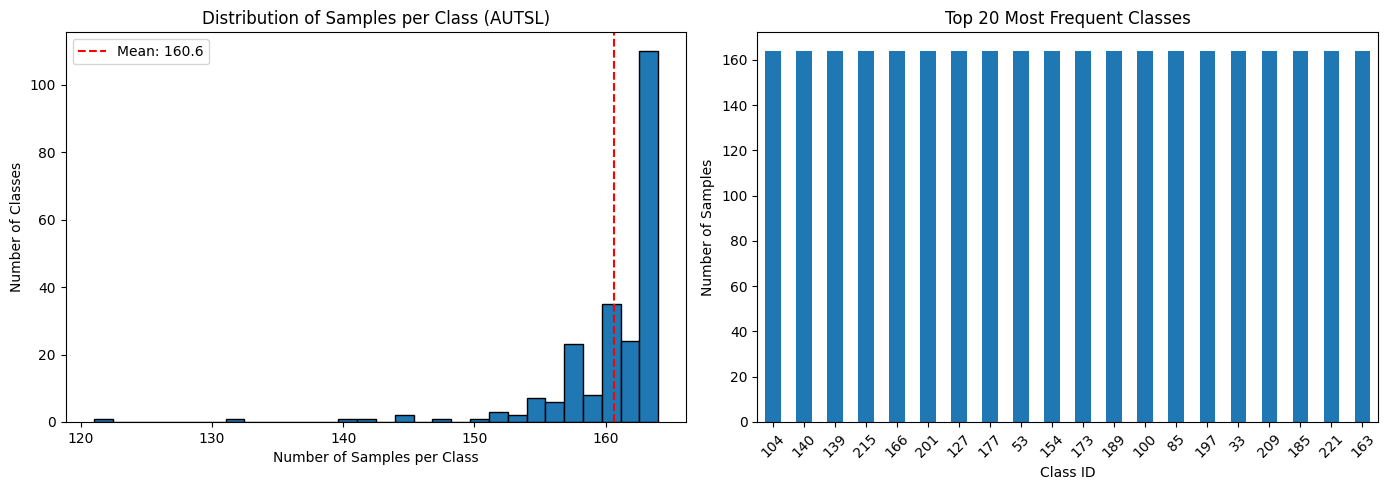

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts = all_labels.value_counts()
axes[0].hist(class_counts.values, bins=30, edgecolor='black')
axes[0].set_xlabel('Number of Samples per Class')
axes[0].set_ylabel('Number of Classes')
axes[0].set_title('Distribution of Samples per Class (AUTSL)')
axes[0].axvline(class_counts.mean(), color='red', linestyle='--', label=f'Mean: {class_counts.mean():.1f}')
axes[0].legend()

class_counts.head(20).plot(kind='bar', ax=axes[1])
axes[1].set_xlabel('Class ID')
axes[1].set_ylabel('Number of Samples')
axes[1].set_title('Top 20 Most Frequent Classes')
axes[1].tick_params(axis='x', rotation=45)
    
plt.tight_layout()
plt.show()

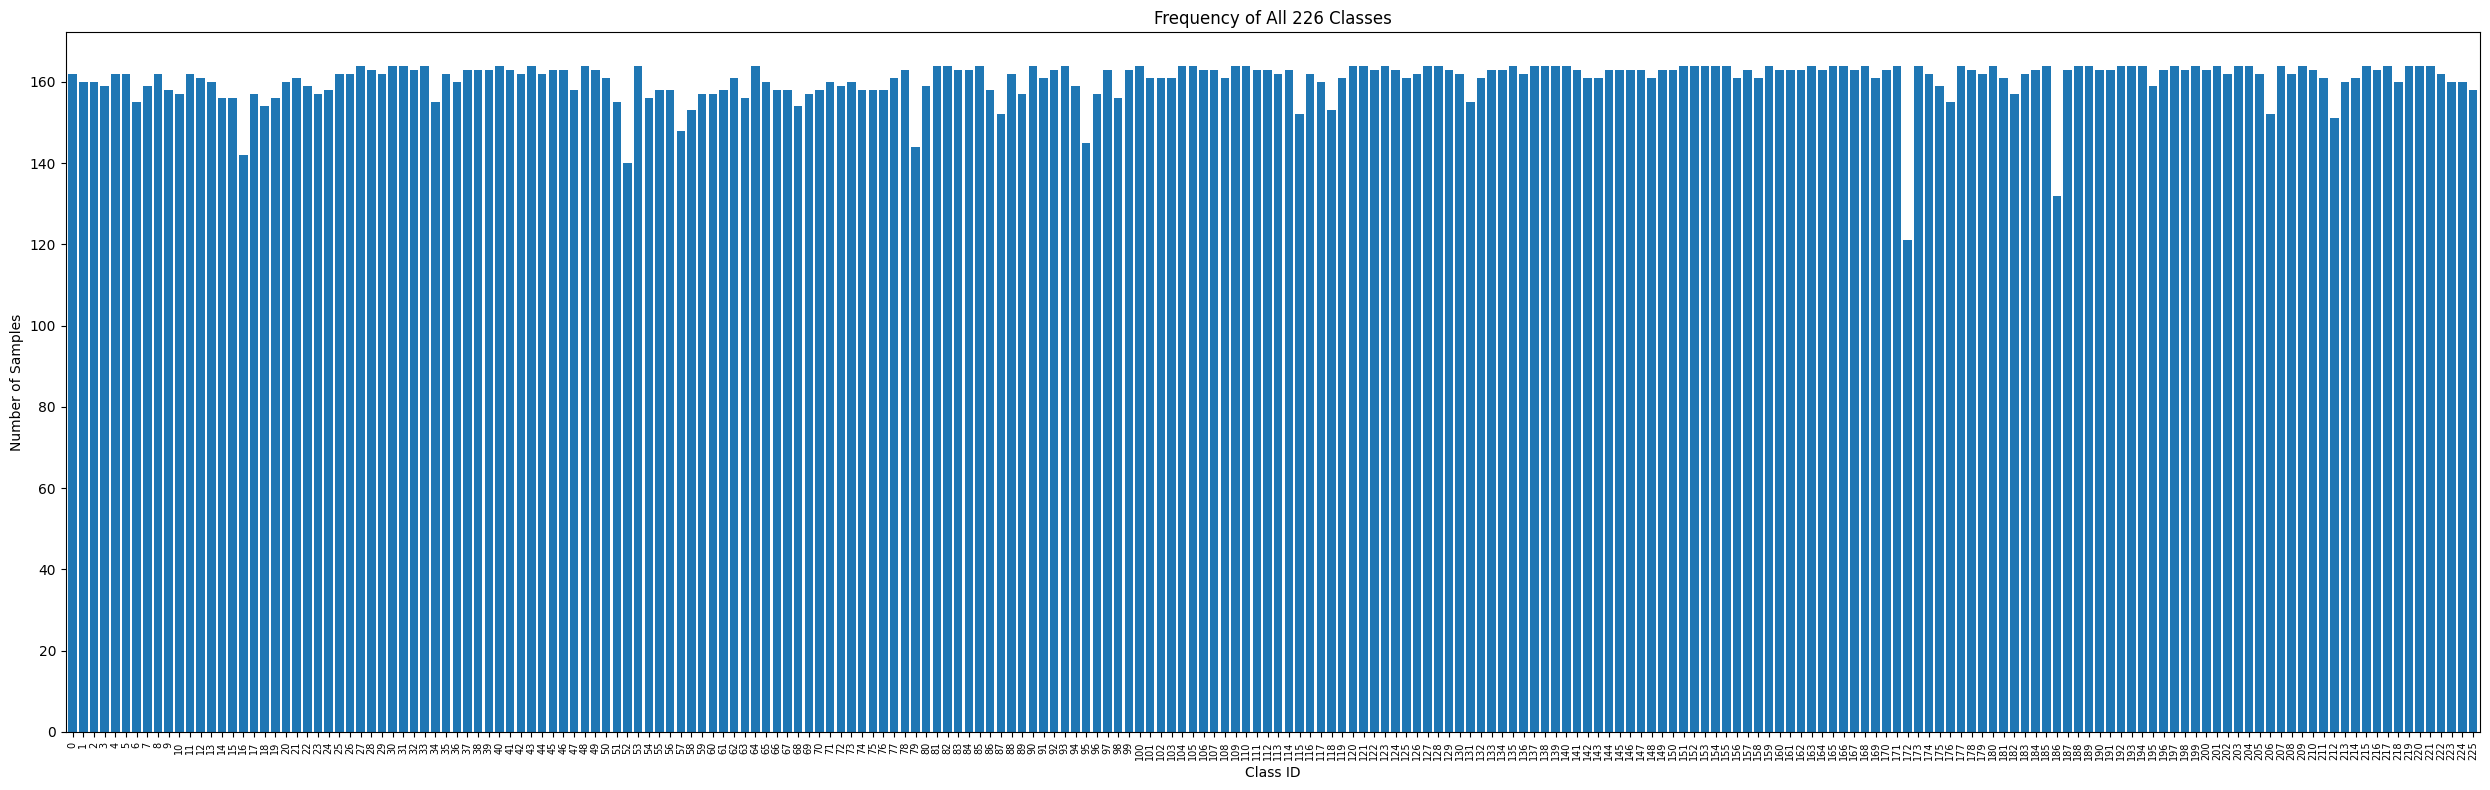

In [52]:
fig, ax = plt.subplots(1, 1, figsize=(25, 8))

all_class_freq = all_labels.value_counts().sort_index()
all_class_freq.plot(kind='bar', ax=ax, width=0.8)

ax.set_xlabel('Class ID')
ax.set_ylabel('Number of Samples')
ax.set_title('Frequency of All 226 Classes')

ax.tick_params(axis='x', rotation=90, labelsize=7)


plt.tight_layout()
plt.show()

In [53]:
print(f"  train.csv: {autsl_train.isnull().sum().sum()}")
print(f"  val.csv: {autsl_val.isnull().sum().sum()}")
print(f"  test.csv: {autsl_test.isnull().sum().sum()}")

  train.csv: 0
  val.csv: 0
  test.csv: 0


In [56]:
train_videos = list((DATA_DIR / "AUTSL" / "train").glob("*.mp4")) + list((DATA_DIR / "AUTSL" / "train").glob("*.avi"))
val_videos = list((DATA_DIR / "AUTSL" / "val").glob("*.mp4")) + list((DATA_DIR / "AUTSL" / "val").glob("*.avi"))
test_videos = list((DATA_DIR / "AUTSL" / "test").glob("*.mp4")) + list((DATA_DIR / "AUTSL" / "test").glob("*.avi"))

print(f"Video files found:")
print(f"  train/: {len(train_videos)} files")
print(f"  val/:   {len(val_videos)} files")
print(f"  test/:  {len(test_videos)} files")
print(f"  Total:  {len(train_videos) + len(val_videos) + len(test_videos)} files")

Video files found:
  train/: 28142 files
  val/:   4418 files
  test/:  3742 files
  Total:  36302 files


In [57]:
print(f"\nSample video files:")
if train_videos:
    print(f"  train/: {train_videos[0].name}")
if val_videos:
    print(f"  val/:   {val_videos[0].name}")
if test_videos:
    print(f"  test/:  {test_videos[0].name}")


Sample video files:
  train/: signer0_sample1000_color.mp4
  val/:   signer11_sample100_color.mp4
  test/:  signer14_sample100_color.mp4


In [59]:
train_class_counts = autsl_train['class_id'].value_counts().sort_index()
val_class_counts = autsl_val['class_id'].value_counts().sort_index()
test_class_counts = autsl_test['class_id'].value_counts().sort_index()

print(f"Classes per split:")
print(f"  Train: {len(train_class_counts)} unique classes")
print(f"  Val:   {len(val_class_counts)} unique classes")
print(f"  Test:  {len(test_class_counts)} unique classes")

Classes per split:
  Train: 226 unique classes
  Val:   226 unique classes
  Test:  226 unique classes


In [60]:
all_class_counts = train_class_counts.add(val_class_counts, fill_value=0).add(test_class_counts, fill_value=0)

print(f"Overall class frequency (all splits combined):")
print(f"  Total classes: {len(all_class_counts)}")
print(f"  Mean samples/class: {all_class_counts.mean():.2f}")
print(f"  Median samples/class: {all_class_counts.median():.2f}")
print(f"  Std deviation: {all_class_counts.std():.2f}")
print(f"  Min (rarest class): {all_class_counts.min()}")
print(f"  Max (most common): {all_class_counts.max()}")
print(f"  Range: {all_class_counts.max() - all_class_counts.min()}")
print(f"  Imbalance ratio (max/min): {all_class_counts.max() / all_class_counts.min():.2f}")

Overall class frequency (all splits combined):
  Total classes: 226
  Mean samples/class: 160.63
  Median samples/class: 162.00
  Std deviation: 5.12
  Min (rarest class): 121
  Max (most common): 164
  Range: 43
  Imbalance ratio (max/min): 1.36


In [61]:
print(f"\nPercentiles:")
for p in [10, 25, 50, 75, 90]:
    print(f"  {p}th percentile: {np.percentile(all_class_counts.values, p):.1f} samples")


Percentiles:
  10th percentile: 156.0 samples
  25th percentile: 159.2 samples
  50th percentile: 162.0 samples
  75th percentile: 164.0 samples
  90th percentile: 164.0 samples


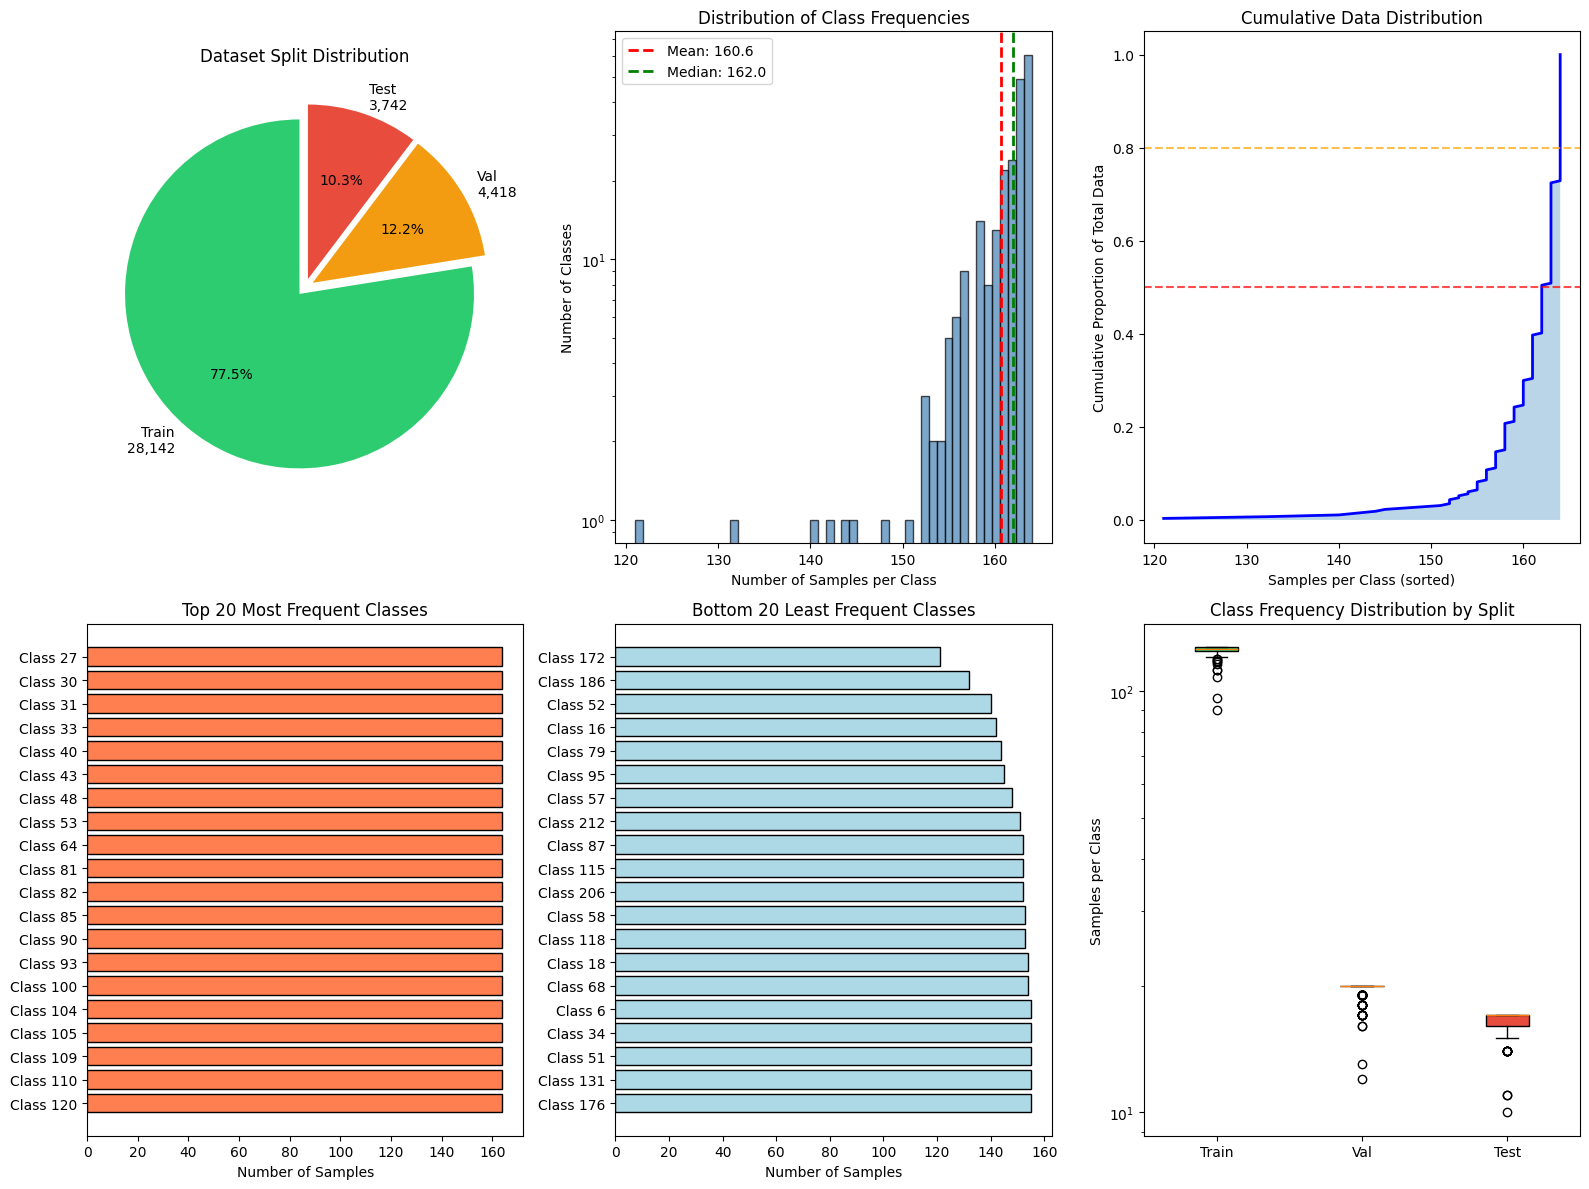

In [63]:
fig = plt.figure(figsize=(16, 12))

# 7.1 Dataset Split Pie Chart
ax1 = fig.add_subplot(2, 3, 1)
sizes = [len(autsl_train), len(autsl_val), len(autsl_test)]
labels = [f'Train\n{len(autsl_train):,}', f'Val\n{len(autsl_val):,}', f'Test\n{len(autsl_test):,}']
colors = ['#2ecc71', '#f39c12', '#e74c3c']
ax1.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, explode=(0.05, 0.05, 0.05))
ax1.set_title('Dataset Split Distribution')

# 7.2 Class Distribution Histogram
ax2 = fig.add_subplot(2, 3, 2)
ax2.hist(all_class_counts.values, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax2.axvline(all_class_counts.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {all_class_counts.mean():.1f}')
ax2.axvline(all_class_counts.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {all_class_counts.median():.1f}')
ax2.set_xlabel('Number of Samples per Class')
ax2.set_ylabel('Number of Classes')
ax2.set_title('Distribution of Class Frequencies')
ax2.legend()
ax2.set_yscale('log')

# 7.3 Cumulative Distribution
ax3 = fig.add_subplot(2, 3, 3)
sorted_counts = np.sort(all_class_counts.values)
cumulative = np.cumsum(sorted_counts) / np.sum(sorted_counts)
ax3.plot(sorted_counts, cumulative, 'b-', linewidth=2)
ax3.fill_between(sorted_counts, cumulative, alpha=0.3)
ax3.set_xlabel('Samples per Class (sorted)')
ax3.set_ylabel('Cumulative Proportion of Total Data')
ax3.set_title('Cumulative Data Distribution')
ax3.axhline(0.5, color='red', linestyle='--', alpha=0.7)
ax3.axhline(0.8, color='orange', linestyle='--', alpha=0.7)

# 7.4 Top 20 Most Frequent Classes
ax4 = fig.add_subplot(2, 3, 4)
top20 = all_class_counts.nlargest(20)
ax4.barh(range(len(top20)), top20.values, color='coral', edgecolor='black')
ax4.set_yticks(range(len(top20)))
ax4.set_yticklabels([f"Class {i}" for i in top20.index])
ax4.set_xlabel('Number of Samples')
ax4.set_title('Top 20 Most Frequent Classes')
ax4.invert_yaxis()

# 7.5 Bottom 20 Least Frequent Classes
ax5 = fig.add_subplot(2, 3, 5)
bottom20 = all_class_counts.nsmallest(20)
ax5.barh(range(len(bottom20)), bottom20.values, color='lightblue', edgecolor='black')
ax5.set_yticks(range(len(bottom20)))
ax5.set_yticklabels([f"Class {i}" for i in bottom20.index])
ax5.set_xlabel('Number of Samples')
ax5.set_title('Bottom 20 Least Frequent Classes')
ax5.invert_yaxis()

# 7.6 Box Plot of Class Frequencies by Split
ax6 = fig.add_subplot(2, 3, 6)
box_data = [train_class_counts.values, val_class_counts.values, test_class_counts.values]
bp = ax6.boxplot(box_data, labels=['Train', 'Val', 'Test'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['#2ecc71', '#f39c12', '#e74c3c']):
    patch.set_facecolor(color)
ax6.set_ylabel('Samples per Class')
ax6.set_title('Class Frequency Distribution by Split')
ax6.set_yscale('log')

plt.tight_layout()
plt.show()

In [66]:
print(f"\nSample mappings (Turkish → English):")
for i in range(min(10, len(class_mapping))):
        print(f"  Class {class_mapping.iloc[i]['ClassId']}: {class_mapping.iloc[i]['TR']} → {class_mapping.iloc[i]['EN']}")


Sample mappings (Turkish → English):
  Class 0: abla → sister
  Class 1: acele → hurry
  Class 2: acikmak → hungry
  Class 3: afiyet_olsun → enjoy_your_meal
  Class 4: agabey → brother
  Class 5: agac → tree
  Class 6: agir → heavy
  Class 7: aglamak → cry
  Class 8: aile → family
  Class 9: akilli → wise


In [69]:
english_words = class_mapping["EN"].dropna().unique()
print(f"\nUnique English words: {len(english_words)}")


Unique English words: 225


In [72]:
english_counts = class_mapping["EN"].value_counts()
polysemous = english_counts[english_counts > 1]
print(f"\nEnglish words with multiple Turkish signs (polysemy):")
for word, count in polysemous.head(10).items():
        turkish_variants = class_mapping[class_mapping["EN"] == word]["TR"].tolist()
        print(f"  '{word}': {count} variants - {turkish_variants}")



English words with multiple Turkish signs (polysemy):
  'you': 2 variants - ['sen', 'siz']


WLASL DATASET


In [75]:
with open('data/WLASL/WLASL_v0.3.json', 'r') as f:
    wlasl_data = json.load(f)

In [76]:
num_signs = len(wlasl_data)
total_instances = sum(len(sign.get('instances', [])) for sign in wlasl_data)
print(f"Total sign classes: {num_signs:,}")
print(f"Total video instances: {total_instances:,}")

Total sign classes: 2,000
Total video instances: 21,083


In [77]:
glosses = [sign['gloss'] for sign in wlasl_data]
gloss_lengths = [len(g) for g in glosses]

print(f"Unique words: {len(set(glosses))}")
print(f"Gloss length statistics:")
print(f"  Mean: {np.mean(gloss_lengths):.2f} characters")
print(f"  Median: {np.median(gloss_lengths):.2f}")
print(f"  Min: {min(gloss_lengths)} ('{glosses[np.argmin(gloss_lengths)]}')")
print(f"  Max: {max(gloss_lengths)} ('{glosses[np.argmax(gloss_lengths)]}')")

Unique words: 2000
Gloss length statistics:
  Mean: 6.01 characters
  Median: 6.00
  Min: 1 ('a')
  Max: 16 ('cochlear implant')


In [80]:
gloss_counts = Counter(glosses)
duplicates = {g: c for g, c in gloss_counts.items() if c > 1}
print(f"Duplicate glosses: {len(duplicates)}")
if duplicates:
    print(f"  Examples: {list(duplicates.items())[:5]}")

Duplicate glosses: 0


In [81]:
print(f"\nSample glosses (first 20):")
for i, gloss in enumerate(glosses[:20]):
    print(f"  {i+1:2d}. {gloss}")


Sample glosses (first 20):
   1. book
   2. drink
   3. computer
   4. before
   5. chair
   6. go
   7. clothes
   8. who
   9. candy
  10. cousin
  11. deaf
  12. fine
  13. help
  14. no
  15. thin
  16. walk
  17. year
  18. yes
  19. all
  20. black


In [82]:
instances_per_sign = []
signers_per_sign = []
all_signer_ids = set()
total_instances = 0

for sign in wlasl_data:
    instances = sign.get('instances', [])
    num_instances = len(instances)
    instances_per_sign.append(num_instances)
    total_instances += num_instances
    
    signer_ids = [inst.get('signer_id', 0) for inst in instances]
    signers_per_sign.append(len(set(signer_ids)))
    all_signer_ids.update(signer_ids)

print(f"Total instances: {total_instances:,}")
print(f"Mean instances per sign: {np.mean(instances_per_sign):.2f}")
print(f"Median instances per sign: {np.median(instances_per_sign):.2f}")
print(f"Std deviation: {np.std(instances_per_sign):.2f}")
print(f"Min instances: {min(instances_per_sign)}")
print(f"Max instances: {max(instances_per_sign)}")
print(f"Unique signers: {len(all_signer_ids)}")

Total instances: 21,083
Mean instances per sign: 10.54
Median instances per sign: 10.00
Std deviation: 3.55
Min instances: 6
Max instances: 40
Unique signers: 119


In [85]:
max_idx = np.argmax(instances_per_sign)
min_idx = np.argmin(instances_per_sign)
print(f"\nMost frequent sign: '{glosses[max_idx]}' ({instances_per_sign[max_idx]} videos)")
print(f"Least frequent sign: '{glosses[min_idx]}' ({instances_per_sign[min_idx]} videos)")


Most frequent sign: 'book' (40 videos)
Least frequent sign: 'caterpillar' (6 videos)


In [86]:
print(f"Mean signers per sign: {np.mean(signers_per_sign):.2f}")
print(f"Median signers per sign: {np.median(signers_per_sign):.2f}")
print(f"Min signers per sign: {min(signers_per_sign)}")
print(f"Max signers per sign: {max(signers_per_sign)}")

Mean signers per sign: 9.39
Median signers per sign: 9.00
Min signers per sign: 4
Max signers per sign: 21


In [87]:
top_diverse = sorted(zip(glosses, signers_per_sign), key=lambda x: x[1], reverse=True)[:5]
print(f"\nTop 5 most diverse signs:")
for gloss, count in top_diverse:
    print(f"  '{gloss}': {count} signers")


Top 5 most diverse signs:
  'who': 21 signers
  'drink': 18 signers
  'deaf': 18 signers
  'no': 18 signers
  'walk': 18 signers


In [88]:
single_signer = sum(1 for x in signers_per_sign if x == 1)
print(f"\nSigns with only 1 signer: {single_signer} ({single_signer/num_signs*100:.1f}%)")


Signs with only 1 signer: 0 (0.0%)


In [89]:
split_counts = {'train': 0, 'val': 0, 'test': 0}
split_videos = {'train': [], 'val': [], 'test': []}

for sign in wlasl_data:
    for inst in sign.get('instances', []):
        split = inst.get('split', 'unknown')
        split_counts[split] = split_counts.get(split, 0) + 1
        split_videos[split].append(inst.get('video_id'))

print(f"Train split: {split_counts.get('train', 0):,} videos")
print(f"Val split:   {split_counts.get('val', 0):,} videos")
print(f"Test split:  {split_counts.get('test', 0):,} videos")

Train split: 14,289 videos
Val split:   3,916 videos
Test split:  2,878 videos


In [90]:
total = sum(split_counts.values())
print(f"\nSplit percentages:")
print(f"  Train: {split_counts.get('train', 0)/total*100:.1f}%")
print(f"  Val:   {split_counts.get('val', 0)/total*100:.1f}%")
print(f"  Test:  {split_counts.get('test', 0)/total*100:.1f}%")


Split percentages:
  Train: 67.8%
  Val:   18.6%
  Test:  13.7%


In [91]:
train_set = set(split_videos.get('train', []))
val_set = set(split_videos.get('val', []))
test_set = set(split_videos.get('test', []))
print(f"\nSplit overlaps:")
print(f"  Train-Val overlap: {len(train_set & val_set)}")
print(f"  Train-Test overlap: {len(train_set & test_set)}")
print(f"  Val-Test overlap: {len(val_set & test_set)}")


Split overlaps:
  Train-Val overlap: 0
  Train-Test overlap: 0
  Val-Test overlap: 0


In [93]:
missing_path = Path("data/WLASL/missing.txt")
if missing_path.exists():
    with open(missing_path, 'r') as f:
        missing_ids = [line.strip() for line in f.readlines()]
    print(f"Missing video IDs in missing.txt: {len(missing_ids)}")
    
    # Check how many of these are actually referenced in the dataset
    all_video_ids = [inst.get('video_id') for sign in wlasl_data for inst in sign.get('instances', [])]
    referenced_missing = [vid for vid in missing_ids if vid in all_video_ids]
    print(f"Referenced but missing: {len(referenced_missing)}")
else:
    print("missing.txt not found - skipping")

Missing video IDs in missing.txt: 9103
Referenced but missing: 9103


In [94]:
sources = []
for sign in wlasl_data:
    for inst in sign.get('instances', []):
        source = inst.get('source', 'unknown')
        sources.append(source)

source_counts = Counter(sources)
print(f"Unique sources: {len(source_counts)}")
print(f"Source distribution:")
for source, count in source_counts.most_common(10):
    print(f"  {source}: {count:,} ({count/len(sources)*100:.1f}%)")

Unique sources: 19
Source distribution:
  signingsavvy: 2,668 (12.7%)
  handspeak: 2,211 (10.5%)
  signschool: 1,968 (9.3%)
  aslsearch: 1,875 (8.9%)
  asldeafined: 1,833 (8.7%)
  aslu: 1,827 (8.7%)
  aslpro: 1,736 (8.2%)
  spreadthesign: 1,584 (7.5%)
  asl5200: 1,561 (7.4%)
  aslsignbank: 1,071 (5.1%)


In [95]:
urls = []
valid_urls = 0
youtube_urls = 0

for sign in wlasl_data:
    for inst in sign.get('instances', []):
        url = inst.get('url', '')
        if url:
            urls.append(url)
            valid_urls += 1
            if 'youtube' in url or 'youtu.be' in url:
                youtube_urls += 1

print(f"Total URLs: {len(urls)}")
print(f"Valid URLs: {valid_urls}")
print(f"YouTube URLs: {youtube_urls}")

Total URLs: 21083
Valid URLs: 21083
YouTube URLs: 5135


In [96]:
print(f"\nSample YouTube URLs:")
for url in urls[:5]:
    print(f"  {url}")


Sample YouTube URLs:
  http://aslbricks.org/New/ASL-Videos/book.mp4
  https://aslsignbank.haskins.yale.edu/dictionary/protected_media/glossvideo/ASL/BO/BOOK-418.mp4
  https://www.youtube.com/watch?v=0UsjUE-TXns
  https://www.youtube.com/watch?v=1QOYOZ3g-aY
  https://www.youtube.com/watch?v=aGtIHKEdCds


In [97]:
if missing_path.exists():
    missing_ids = [line.strip() for line in open(missing_path).readlines()]
    
    # Check if missing IDs are numeric
    numeric_ids = [vid for vid in missing_ids if vid.isdigit()]
    print(f"Numeric IDs: {len(numeric_ids)}")
    print(f"Non-numeric IDs: {len(missing_ids) - len(numeric_ids)}")
    
    # Sample missing IDs
    print(f"\nSample missing IDs (first 20):")
    for vid in missing_ids[:20]:
        print(f"  {vid}")

Numeric IDs: 9103
Non-numeric IDs: 0

Sample missing IDs (first 20):
  65225
  68011
  68208
  68012
  70212
  70266
  07085
  07086
  07087
  07088
  07089
  07090
  07091
  07092
  07093
  07094
  07095
  07096
  07097
  07098


In [98]:
missing_in_train = sum(1 for vid in missing_ids if vid in split_videos.get('train', []))
missing_in_val = sum(1 for vid in missing_ids if vid in split_videos.get('val', []))
missing_in_test = sum(1 for vid in missing_ids if vid in split_videos.get('test', []))
    
print(f"\nMissing IDs by split:")
print(f"  Train: {missing_in_train}")
print(f"  Val:   {missing_in_val}")
print(f"  Test:  {missing_in_test}")


Missing IDs by split:
  Train: 5976
  Val:   1663
  Test:  1464


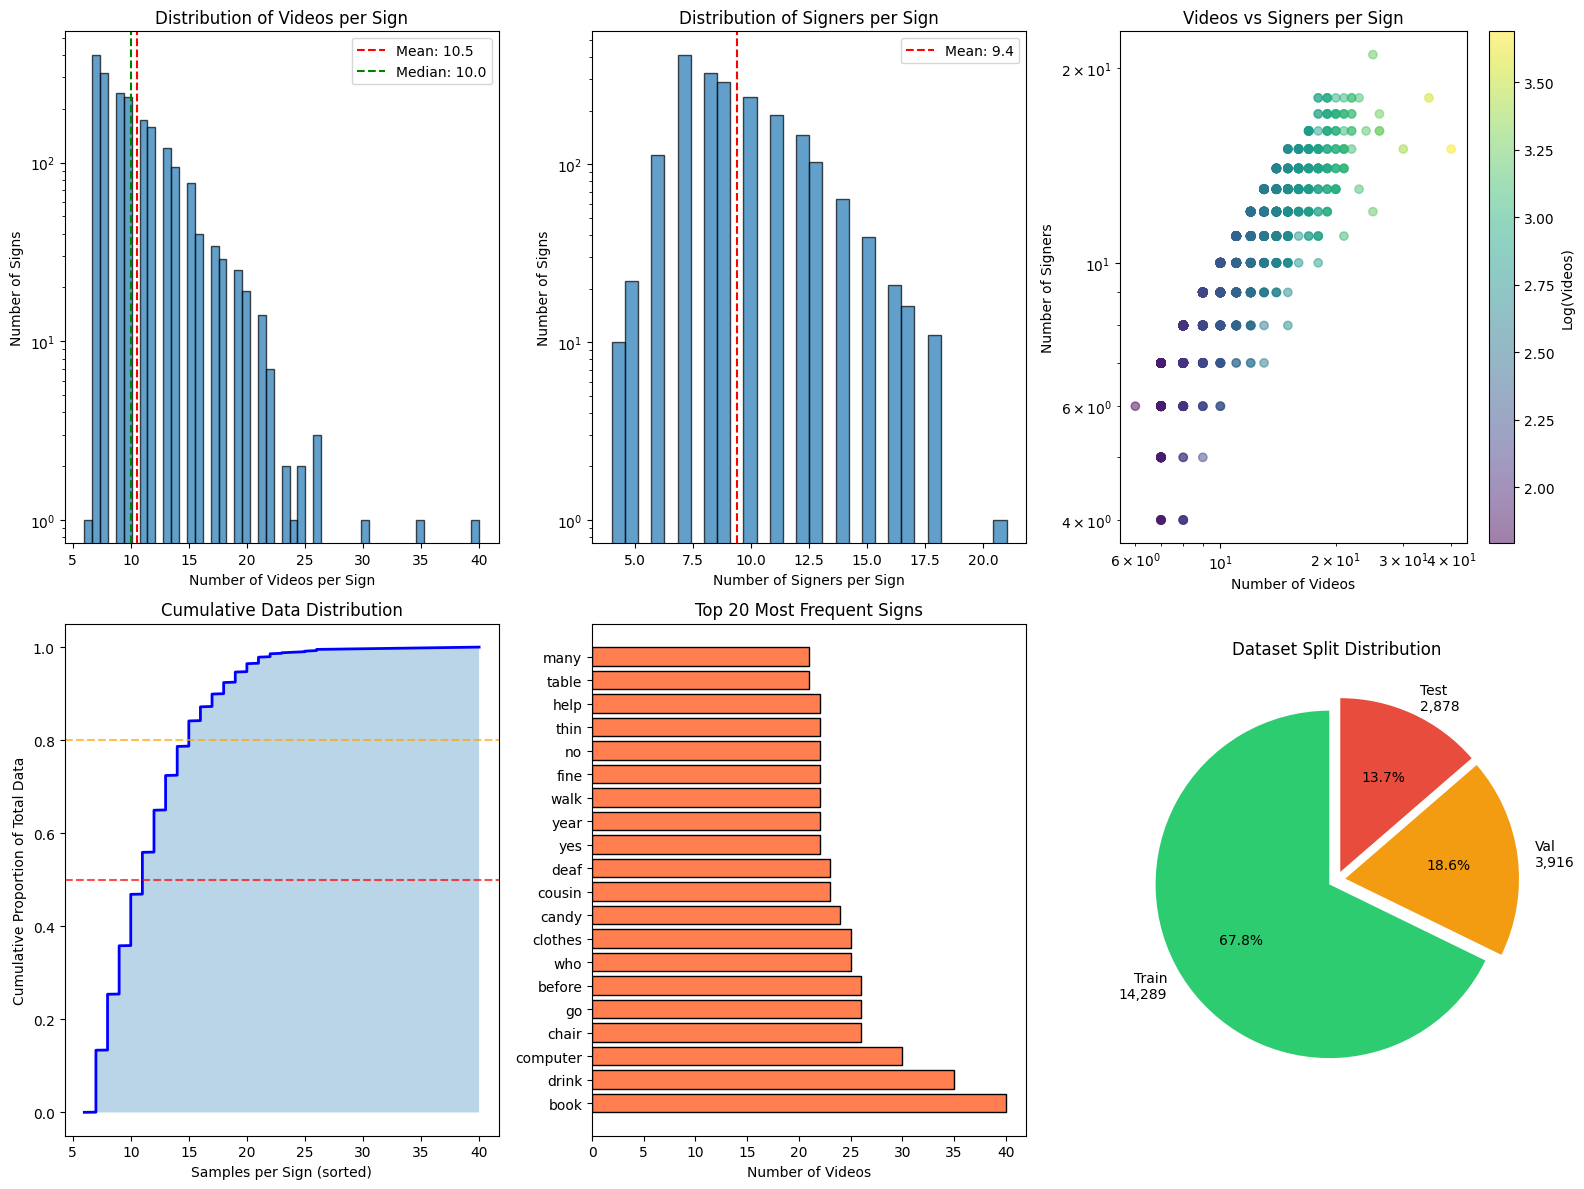

In [100]:
fig = plt.figure(figsize=(16, 12))

# 10.1 Instance distribution histogram
ax1 = fig.add_subplot(2, 3, 1)
ax1.hist(instances_per_sign, bins=50, edgecolor='black', alpha=0.7)
ax1.axvline(np.mean(instances_per_sign), color='red', linestyle='--', label=f'Mean: {np.mean(instances_per_sign):.1f}')
ax1.axvline(np.median(instances_per_sign), color='green', linestyle='--', label=f'Median: {np.median(instances_per_sign):.1f}')
ax1.set_xlabel('Number of Videos per Sign')
ax1.set_ylabel('Number of Signs')
ax1.set_title('Distribution of Videos per Sign')
ax1.legend()
ax1.set_yscale('log')

# 10.2 Signer distribution histogram
ax2 = fig.add_subplot(2, 3, 2)
ax2.hist(signers_per_sign, bins=30, edgecolor='black', alpha=0.7)
ax2.axvline(np.mean(signers_per_sign), color='red', linestyle='--', label=f'Mean: {np.mean(signers_per_sign):.1f}')
ax2.set_xlabel('Number of Signers per Sign')
ax2.set_ylabel('Number of Signs')
ax2.set_title('Distribution of Signers per Sign')
ax2.legend()
ax2.set_yscale('log')

# 10.3 Scatter plot: instances vs signers
ax3 = fig.add_subplot(2, 3, 3)
scatter = ax3.scatter(instances_per_sign, signers_per_sign, alpha=0.5, c=np.log(instances_per_sign), cmap='viridis')
ax3.set_xlabel('Number of Videos')
ax3.set_ylabel('Number of Signers')
ax3.set_title('Videos vs Signers per Sign')
ax3.set_xscale('log')
ax3.set_yscale('log')
plt.colorbar(scatter, ax=ax3, label='Log(Videos)')

# 10.4 Cumulative distribution
ax4 = fig.add_subplot(2, 3, 4)
sorted_instances = np.sort(instances_per_sign)
cumulative = np.cumsum(sorted_instances) / np.sum(sorted_instances)
ax4.plot(sorted_instances, cumulative, 'b-', linewidth=2)
ax4.fill_between(sorted_instances, cumulative, alpha=0.3)
ax4.set_xlabel('Samples per Sign (sorted)')
ax4.set_ylabel('Cumulative Proportion of Total Data')
ax4.set_title('Cumulative Data Distribution')
ax4.axhline(0.5, color='red', linestyle='--', alpha=0.7)
ax4.axhline(0.8, color='orange', linestyle='--', alpha=0.7)

# 10.5 Top 20 most frequent signs
ax5 = fig.add_subplot(2, 3, 5)
top20_idx = np.argsort(instances_per_sign)[-20:]
top20_glosses = [glosses[i] for i in top20_idx]
top20_counts = [instances_per_sign[i] for i in top20_idx]
ax5.barh(range(20), top20_counts, color='coral', edgecolor='black')
ax5.set_yticks(range(20))
ax5.set_yticklabels(top20_glosses)
ax5.set_xlabel('Number of Videos')
ax5.set_title('Top 20 Most Frequent Signs')
ax5.invert_yaxis()

# 10.6 Pie chart: split distribution
ax6 = fig.add_subplot(2, 3, 6)
sizes = [split_counts.get('train', 0), split_counts.get('val', 0), split_counts.get('test', 0)]
labels = [f'Train\n{sizes[0]:,}', f'Val\n{sizes[1]:,}', f'Test\n{sizes[2]:,}']
colors = ['#2ecc71', '#f39c12', '#e74c3c']
ax6.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, explode=(0.05, 0.05, 0.05))
ax6.set_title('Dataset Split Distribution')

plt.tight_layout()
plt.show()




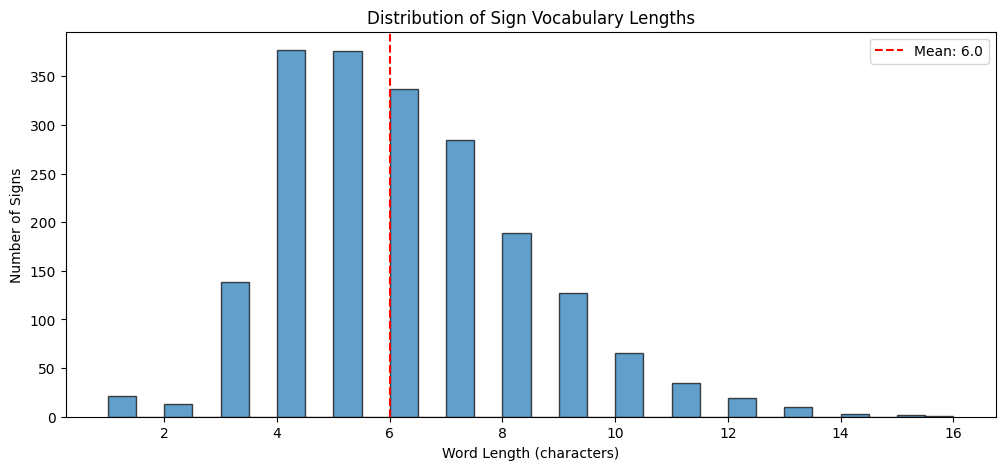

In [101]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(gloss_lengths, bins=30, edgecolor='black', alpha=0.7)
ax.set_xlabel('Word Length (characters)')
ax.set_ylabel('Number of Signs')
ax.set_title('Distribution of Sign Vocabulary Lengths')
ax.axvline(np.mean(gloss_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(gloss_lengths):.1f}')
ax.legend()
plt.show()

EMOSIGN DATASET

In [102]:
emosign_df = pd.read_csv('data/emosign/emosign_dataset.csv')

In [103]:
print(f"Total samples: {len(emosign_df):,}")
print(f"Total columns: {len(emosign_df.columns)}")
print(f"Missing values: {emosign_df.isnull().sum().sum()}")
print(f"Duplicate rows: {emosign_df.duplicated().sum()}")

Total samples: 200
Total columns: 15
Missing values: 0
Duplicate rows: 0


In [104]:
print(f"\nColumn names:")
for i, col in enumerate(emosign_df.columns):
    print(f"  {i+1:2d}. {col}")


Column names:
   1. video_name
   2. Sentiment
   3. joy
   4. excited
   5. surprise_pos
   6. surprise_neg
   7. worry
   8. sadness
   9. fear
  10. disgust
  11. frustration
  12. anger
  13. Reasoning_1
  14. Reasoning_2
  15. Reasoning_3


In [105]:
print("Data types:")
print(emosign_df.dtypes)

Data types:
video_name        str
Sentiment       int64
joy             int64
excited         int64
surprise_pos    int64
surprise_neg    int64
worry           int64
sadness         int64
fear            int64
disgust         int64
frustration     int64
anger           int64
Reasoning_1       str
Reasoning_2       str
Reasoning_3       str
dtype: object


In [107]:
missing = emosign_df.isnull().sum()
missing_pct = (missing / len(emosign_df)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
print(missing_df[missing_df['Missing'] > 0] if missing_df['Missing'].sum() > 0 else "No missing values")

No missing values


In [109]:
sentiment_scores = emosign_df['Sentiment'].dropna()

print(f"Sentiment column: Sentiment")
print(f"Valid scores: {len(sentiment_scores)} / {len(emosign_df)}")
print(f"\nScore statistics:")
print(f"  Min: {sentiment_scores.min()}")
print(f"  Max: {sentiment_scores.max()}")
print(f"  Mean: {sentiment_scores.mean():.2f}")
print(f"  Median: {sentiment_scores.median():.2f}")
print(f"  Std: {sentiment_scores.std():.2f}")

Sentiment column: Sentiment
Valid scores: 200 / 200

Score statistics:
  Min: -3
  Max: 3
  Mean: -0.25
  Median: -1.00
  Std: 2.18


In [110]:
for score in sorted(sentiment_scores.unique()):
    count = (sentiment_scores == score).sum()
    print(f"  Score {score}: {count} ({count/len(sentiment_scores)*100:.1f}%)")

  Score -3: 29 (14.5%)
  Score -2: 49 (24.5%)
  Score -1: 43 (21.5%)
  Score 0: 3 (1.5%)
  Score 1: 12 (6.0%)
  Score 2: 26 (13.0%)
  Score 3: 38 (19.0%)


In [111]:
sentiment_categories = []
for score in sentiment_scores:
    if score < 0:
        sentiment_categories.append('Negative')
    elif score == 0:
        sentiment_categories.append('Neutral')
    else:
        sentiment_categories.append('Positive')

cat_counts = Counter(sentiment_categories)
print(f"\nSentiment category distribution:")
for cat, count in cat_counts.items():
    print(f"  {cat}: {count} ({count/len(sentiment_categories)*100:.1f}%)")


Sentiment category distribution:
  Positive: 76 (38.0%)
  Negative: 121 (60.5%)
  Neutral: 3 (1.5%)


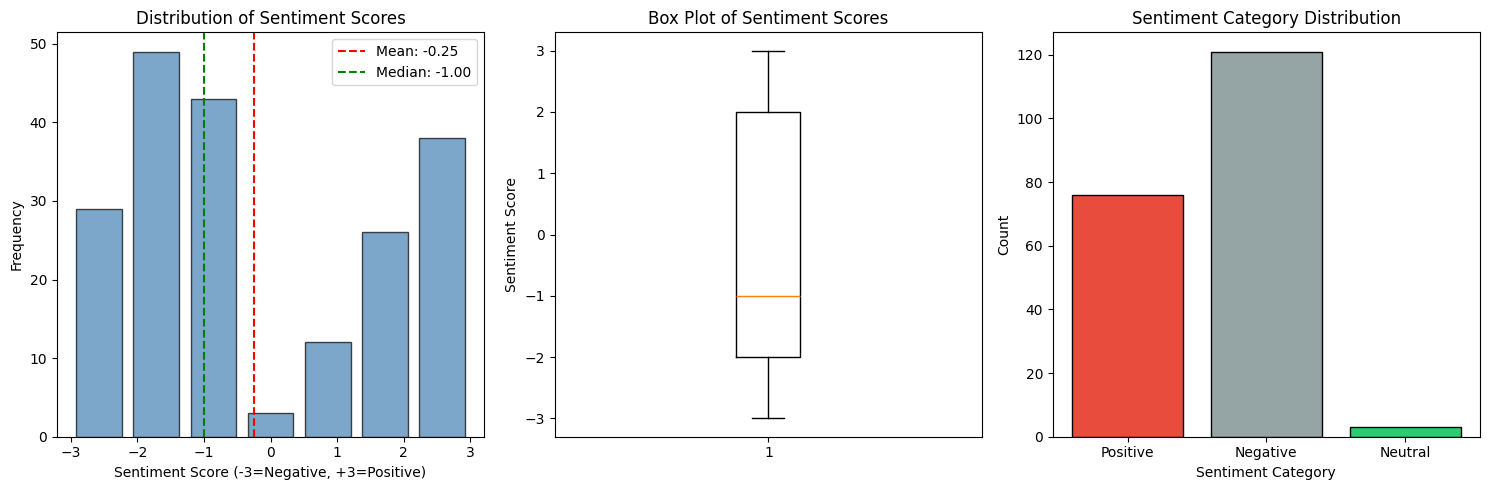

In [112]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Histogram
axes[0].hist(sentiment_scores, bins=7, edgecolor='black', alpha=0.7, rwidth=0.8, color='steelblue')
axes[0].set_xlabel('Sentiment Score (-3=Negative, +3=Positive)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Sentiment Scores')
axes[0].axvline(sentiment_scores.mean(), color='red', linestyle='--', label=f'Mean: {sentiment_scores.mean():.2f}')
axes[0].axvline(sentiment_scores.median(), color='green', linestyle='--', label=f'Median: {sentiment_scores.median():.2f}')
axes[0].legend()

# Box plot
axes[1].boxplot(sentiment_scores, vert=True)
axes[1].set_ylabel('Sentiment Score')
axes[1].set_title('Box Plot of Sentiment Scores')

# Bar chart by category
axes[2].bar(cat_counts.keys(), cat_counts.values(), color=['#e74c3c', '#95a5a6', '#2ecc71'], edgecolor='black')
axes[2].set_xlabel('Sentiment Category')
axes[2].set_ylabel('Count')
axes[2].set_title('Sentiment Category Distribution')

plt.tight_layout()
plt.show()

In [114]:
emotion_stats = {}
for col in existing_emotion_cols:
    values = emosign_df[col].dropna()
    emotion_stats[col] = {
        'mean': values.mean(),
        'median': values.median(),
        'std': values.std(),
        'min': values.min(),
        'max': values.max(),
        'samples': len(values)
    }
    print(f"\n{col.upper()}:")
    print(f"  Mean: {values.mean():.2f}, Median: {values.median():.2f}, Std: {values.std():.2f}")
    print(f"  Range: {values.min()} to {values.max()}")
    print(f"  Valid samples: {len(values)}/{len(emosign_df)}")


JOY:
  Mean: 1.76, Median: 1.00, Std: 1.13
  Range: 1 to 4
  Valid samples: 200/200

EXCITED:
  Mean: 1.75, Median: 1.00, Std: 1.11
  Range: 1 to 4
  Valid samples: 200/200

SURPRISE_POS:
  Mean: 1.44, Median: 1.00, Std: 0.92
  Range: 1 to 4
  Valid samples: 200/200

SURPRISE_NEG:
  Mean: 1.20, Median: 1.00, Std: 0.59
  Range: 1 to 4
  Valid samples: 200/200

WORRY:
  Mean: 1.50, Median: 1.00, Std: 0.95
  Range: 1 to 4
  Valid samples: 200/200

SADNESS:
  Mean: 1.47, Median: 1.00, Std: 0.90
  Range: 1 to 4
  Valid samples: 200/200

FEAR:
  Mean: 1.32, Median: 1.00, Std: 0.84
  Range: 1 to 4
  Valid samples: 200/200

DISGUST:
  Mean: 1.30, Median: 1.00, Std: 0.80
  Range: 1 to 4
  Valid samples: 200/200

FRUSTRATION:
  Mean: 1.56, Median: 1.00, Std: 1.04
  Range: 1 to 4
  Valid samples: 200/200

ANGER:
  Mean: 1.20, Median: 1.00, Std: 0.61
  Range: 1 to 4
  Valid samples: 200/200


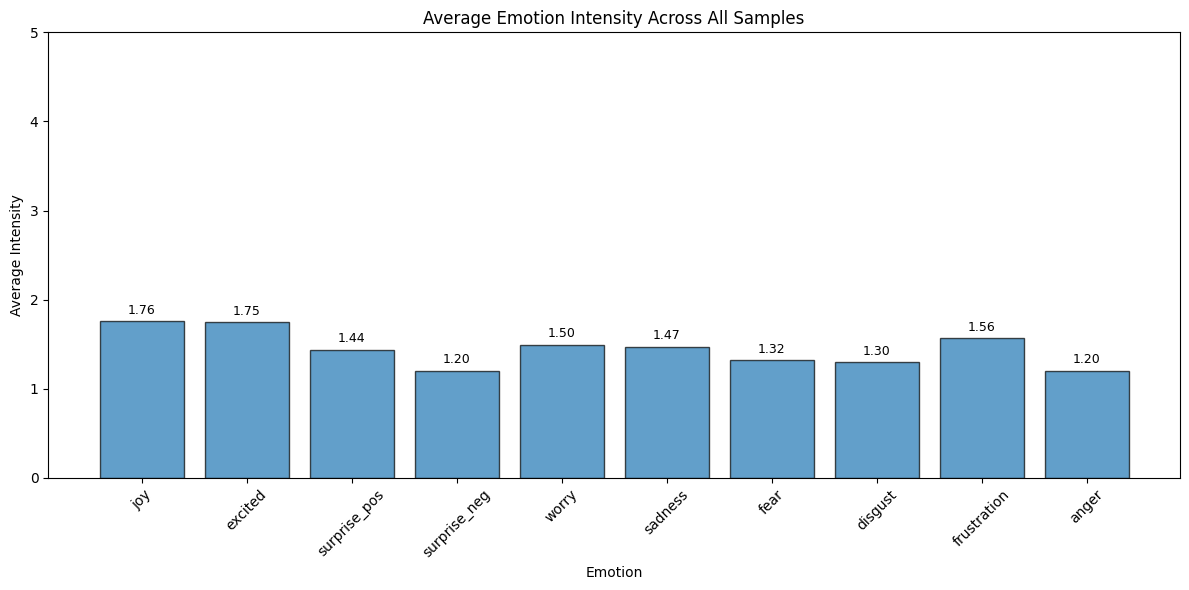

In [115]:
if existing_emotion_cols:
    fig, ax = plt.subplots(figsize=(12, 6))
    means = [emotion_stats[col]['mean'] for col in existing_emotion_cols]
    bars = ax.bar(existing_emotion_cols, means, edgecolor='black', alpha=0.7)
    ax.set_xlabel('Emotion')
    ax.set_ylabel('Average Intensity')
    ax.set_title('Average Emotion Intensity Across All Samples')
    ax.set_ylim(0, 5)
    ax.tick_params(axis='x', rotation=45)
    
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
                f'{mean:.2f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()

In [116]:
reasoning_cols = ['Reasoning_1', 'Reasoning_2', 'Reasoning_3']
reasoning_cols = [col for col in reasoning_cols if col in emosign_df.columns]

for col in reasoning_cols:
    non_empty = emosign_df[col].dropna()
    non_empty_count = len(non_empty)
    non_empty_pct = non_empty_count / len(emosign_df) * 100
    print(f"{col}: {non_empty_count} non-empty ({non_empty_pct:.1f}%)")
    
    # Show sample reasoning text
    if non_empty_count > 0:
        print(f"  Sample: {non_empty.iloc[0][:100]}...")

Reasoning_1: 200 non-empty (100.0%)
  Sample: presenting 2 different directions that people can branch off to...with no judgment...flat expression...
Reasoning_2: 200 non-empty (100.0%)
  Sample: head tiled down and head tiled up ..  eye brow raised ...
Reasoning_3: 200 non-empty (100.0%)
  Sample: slight smile on face when signing the statement suggesting postive cues ...


In [117]:
correlations = {}
for col in existing_emotion_cols:
    # Use only rows where both sentiment and emotion have valid values
    valid_mask = emosign_df['Sentiment'].notna() & emosign_df[col].notna()
    if valid_mask.sum() > 0:
        corr = emosign_df.loc[valid_mask, 'Sentiment'].corr(emosign_df.loc[valid_mask, col])
        correlations[col] = corr
        print(f"  Sentiment vs {col}: {corr:.4f}")

  Sentiment vs joy: 0.8440
  Sentiment vs excited: 0.8133
  Sentiment vs surprise_pos: 0.5624
  Sentiment vs surprise_neg: -0.2138
  Sentiment vs worry: -0.4175
  Sentiment vs sadness: -0.4231
  Sentiment vs fear: -0.3581
  Sentiment vs disgust: -0.2645
  Sentiment vs frustration: -0.4232
  Sentiment vs anger: -0.2987


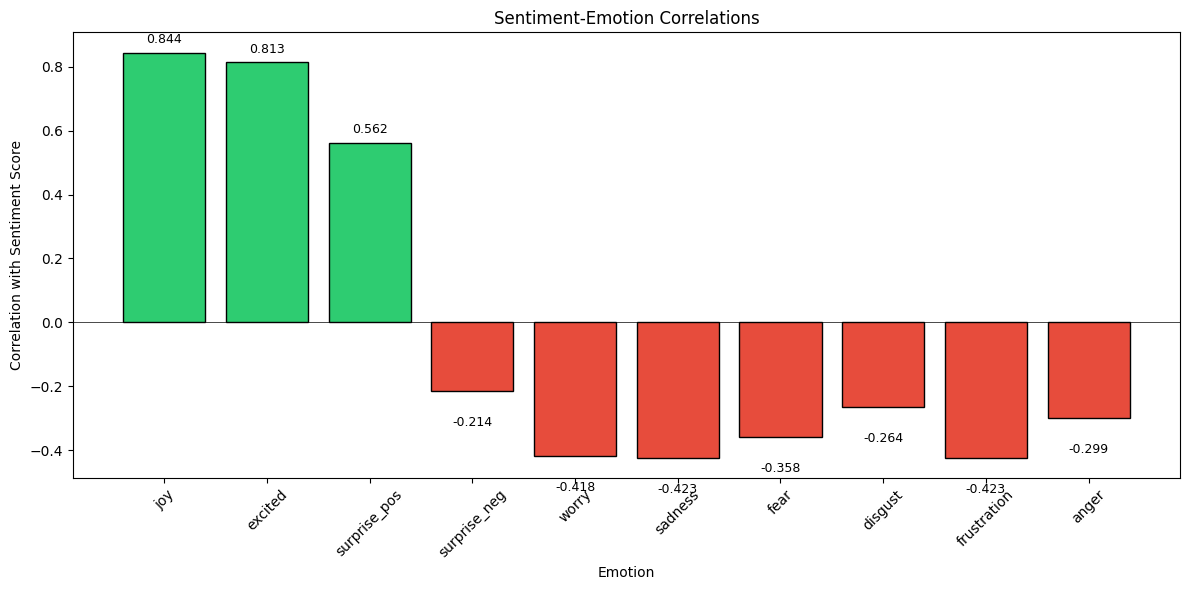

In [118]:
if correlations:
    fig, ax = plt.subplots(figsize=(12, 6))
    cols = list(correlations.keys())
    corr_values = list(correlations.values())
    colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in corr_values]
    bars = ax.bar(cols, corr_values, color=colors, edgecolor='black')
    ax.set_xlabel('Emotion')
    ax.set_ylabel('Correlation with Sentiment Score')
    ax.set_title('Sentiment-Emotion Correlations')
    ax.axhline(0, color='black', linestyle='-', linewidth=0.5)
    ax.tick_params(axis='x', rotation=45)
    
    for bar, corr in zip(bars, corr_values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.02 if corr >= 0 else -0.08), 
                f'{corr:.3f}', ha='center', va='bottom' if corr >= 0 else 'top', fontsize=9)
    
    plt.tight_layout()
    plt.show()

In [121]:
high_intensity_threshold = 4
high_emotion_samples = {}

for col in existing_emotion_cols:
    high_count = (emosign_df[col] >= high_intensity_threshold).sum()
    high_emotion_samples[col] = high_count
    if high_count > 0:
        print(f"  {col} intensity >= {high_intensity_threshold}: {high_count} samples ({high_count/len(emosign_df)*100:.1f}%)")

  joy intensity >= 4: 28 samples (14.0%)
  excited intensity >= 4: 27 samples (13.5%)
  surprise_pos intensity >= 4: 15 samples (7.5%)
  surprise_neg intensity >= 4: 3 samples (1.5%)
  worry intensity >= 4: 15 samples (7.5%)
  sadness intensity >= 4: 14 samples (7.0%)
  fear intensity >= 4: 15 samples (7.5%)
  disgust intensity >= 4: 12 samples (6.0%)
  frustration intensity >= 4: 22 samples (11.0%)
  anger intensity >= 4: 5 samples (2.5%)


In [122]:
pos_emotions = [col for col in existing_emotion_cols if col in ['joy', 'excited', 'surprise_pos']]
if pos_emotions:
    emosign_df['avg_positive'] = emosign_df[pos_emotions].mean(axis=1)

# Create a column for average negative emotion
neg_emotions = [col for col in existing_emotion_cols if col in ['surprise_neg', 'worry', 'sadness', 'fear', 'disgust', 'frustration', 'anger']]
if neg_emotions:
    emosign_df['avg_negative'] = emosign_df[neg_emotions].mean(axis=1)

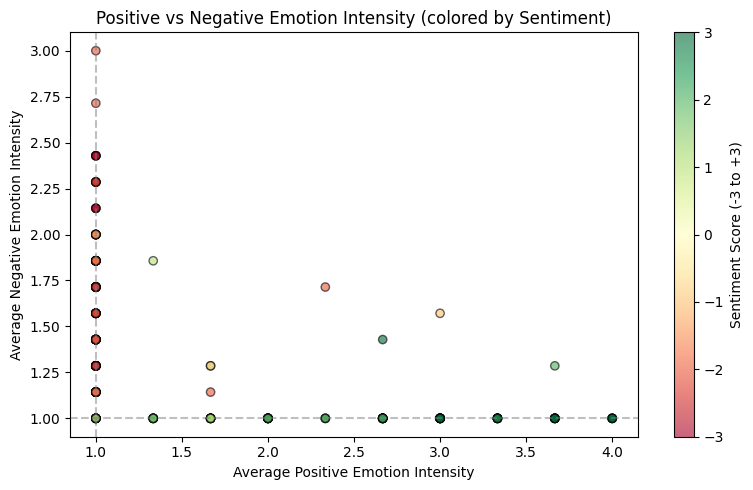

In [125]:
if 'avg_positive' in emosign_df.columns and 'avg_negative' in emosign_df.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    scatter = ax.scatter(emosign_df['avg_positive'], emosign_df['avg_negative'], 
                        c=emosign_df['Sentiment'], cmap='RdYlGn', alpha=0.6, edgecolors='black')
    ax.set_xlabel('Average Positive Emotion Intensity')
    ax.set_ylabel('Average Negative Emotion Intensity')
    ax.set_title('Positive vs Negative Emotion Intensity (colored by Sentiment)')
    ax.axhline(1, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(1, color='gray', linestyle='--', alpha=0.5)
    cbar = plt.colorbar(scatter)
    cbar.set_label('Sentiment Score (-3 to +3)')
    plt.tight_layout()
    plt.show()

In [127]:
missing_counts = emosign_df.isnull().sum()
missing_pct = missing_counts / len(emosign_df) * 100

for col in emosign_df.columns:
    if missing_counts[col] > 0:
        print(f"  {col}: {missing_counts[col]} missing ({missing_pct[col]:.1f}%)")